# Object Detection using COCO Dataset

## Objective
To understand the fundamentals of object detection, differentiate it from image classification, and explore the COCO dataset used to train modern detection models.

## Introduction

Computer vision enables machines to interpret and understand visual data from the world. Two fundamental tasks in computer vision are:

- Image Classification
- Object Detection

## Image Classification

Image classification assigns a single label to an entire image.

Example:
- Input: Image of a dog
- Output: "Dog"

The model does not identify where the object is located, only what is present.

<img src="https://www.mathworks.com/help/examples/nnet/win64/MultilabelImageClassificationUsingDeepLearningExample_01.png" width="1000" height="400">

## Object Detection

Object detection identifies multiple objects in an image and localizes them using bounding boxes.

Each detection includes:
- Class label
- Bounding box (location)
- Confidence score

<img src="https://cdn.prod.website-files.com/62fba5686b6d47653f1ed2ae/66ba4dd3b1dcc06c0107ddbf_AD_4nXdX13QEoZESHyxwjFGiIxiNkbBQHHur0PuG5DTdOjieDAYBew8RKc6l4nOymVoBSCXP3VL_Ul2bUHTiyHGESwY1LNL1y9HPtq-Okazo6ljxBVoJ6HprKHxYw_OBuHOwB0NoAOl4F-Jy3n7K4xSjNHEohmnn.png" width="800" height="400">

## Difference between Image Classification and Object Detection

| Feature | Image Classification | Object Detection |
|--------|---------------------|------------------|
| Output | Single label | Multiple labels |
| Localization | Not included | Bounding boxes |
| Complexity | Low | High |
| Use case | Identify object | Identify + locate objects |

## Applications

Image Classification:
- Medical diagnosis (disease classification)
- Image tagging
- Content filtering

Object Detection:
- Autonomous driving (cars, pedestrians)
- Surveillance systems
- Face detection
- Smart agriculture (crop monitoring)

## Why Data is Important

Object detection models require large annotated datasets containing:
- Images
- Object labels
- Bounding boxes

These datasets enable models to learn both classification and localization.

## COCO Dataset

The COCO (Common Objects in Context) dataset is a large-scale dataset used for training and evaluating object detection models.

It contains real-world images with multiple objects and detailed annotations.

#### COCO Dataset Example

<img src="https://framerusercontent.com/images/yQkzcfolTF1Jjrh0PdvCnnbpMgA.webp?height=800&width=1300" width="800" height="400">

## Components of COCO Dataset

1. Images
   - Real-world complex scenes

2. Annotations
   - Bounding boxes
   - Class labels
   - Segmentation masks

3. Categories
   - 80 object classes (person, car, dog, etc.)

## Annotation Format in COCO

COCO uses the format:

(x, y, width, height)

Where:
- (x, y) = top-left corner
- width, height = size of bounding box

In [2]:
# Example in Json format

{
  "image_id": 1,
  "category_id": 18,
  "bbox": [50, 100, 150, 200]
}

{'image_id': 1, 'category_id': 18, 'bbox': [50, 100, 150, 200]}

## Importance of COCO Dataset

- Provides diverse real-world scenarios
- Contains multiple objects per image
- Standard benchmark for evaluation
- Used to train pretrained models

## Pretrained Object Detection Models

Modern models are trained on large datasets like COCO to learn general features.

Examples include:
- Faster R-CNN
- YOLO
- SSD

These pretrained models can be directly used or fine-tuned for specific tasks.

## Transition to YOLO

While COCO provides annotations in (x, y, width, height) format, models like YOLO require a different format based on normalized center coordinates.

In the next section, we will convert COCO annotations into YOLO format and understand how YOLO uses this data for detection.

In [3]:
# Install if needed
# !pip install pycocotools matplotlib opencv-python

import json
import cv2
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import os

In [5]:
# Download annotations
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip annotations_trainval2017.zip

--2026-04-08 16:32:38--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.204.160, 52.217.76.212, 16.15.207.224, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.204.160|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘annotations_trainval2017.zip’

annotations_trainva 100%[===================>] 241.19M  58.7MB/s    in 4.5s    

2026-04-08 16:32:43 (53.3 MB/s) - ‘annotations_trainval2017.zip’ saved [252907541/252907541]

Archive:  annotations_trainval2017.zip
  inflating: annotations/instances_train2017.json  
  inflating: annotations/instances_val2017.json  
  inflating: annotations/captions_train2017.json  
  inflating: annotations/captions_val2017.json  
  inflating: annotations/person_keypoints_train2017.json  
  inflating: annotations/person_keypoints_val2017.json  


In [11]:
# Download small validation images
!wget http://images.cocodataset.org/zips/val2017.zip
!unzip val2017.zip

Streaming output truncated to the last 5000 lines.
 extracting: val2017/000000212226.jpg  
 extracting: val2017/000000231527.jpg  
 extracting: val2017/000000578922.jpg  
 extracting: val2017/000000062808.jpg  
 extracting: val2017/000000119038.jpg  
 extracting: val2017/000000114871.jpg  
 extracting: val2017/000000463918.jpg  
 extracting: val2017/000000365745.jpg  
 extracting: val2017/000000320425.jpg  
 extracting: val2017/000000481404.jpg  
 extracting: val2017/000000314294.jpg  
 extracting: val2017/000000335328.jpg  
 extracting: val2017/000000513688.jpg  
 extracting: val2017/000000158548.jpg  
 extracting: val2017/000000132116.jpg  
 extracting: val2017/000000415238.jpg  
 extracting: val2017/000000321333.jpg  
 extracting: val2017/000000081738.jpg  
 extracting: val2017/000000577584.jpg  
 extracting: val2017/000000346905.jpg  
 extracting: val2017/000000433980.jpg  
 extracting: val2017/000000228144.jpg  
 extracting: val2017/000000041872.jpg  
 extracting: val2017/00000011

In [45]:
ann_file = "annotations/instances_val2017.json"
coco = COCO(ann_file)

loading annotations into memory...
Done (t=1.37s)
creating index...
index created!


In [46]:
print("Number of images:", len(coco.imgs))
print("Number of annotations:", len(coco.anns))
print("Number of categories:", len(coco.cats))

Number of images: 5000
Number of annotations: 36781
Number of categories: 80


In [47]:
categories = coco.loadCats(coco.getCatIds())
category_names = [cat['name'] for cat in categories]

print(category_names[:10])

['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


In [48]:
coco.cats

{1: {'supercategory': 'person', 'id': 1, 'name': 'person'},
 2: {'supercategory': 'vehicle', 'id': 2, 'name': 'bicycle'},
 3: {'supercategory': 'vehicle', 'id': 3, 'name': 'car'},
 4: {'supercategory': 'vehicle', 'id': 4, 'name': 'motorcycle'},
 5: {'supercategory': 'vehicle', 'id': 5, 'name': 'airplane'},
 6: {'supercategory': 'vehicle', 'id': 6, 'name': 'bus'},
 7: {'supercategory': 'vehicle', 'id': 7, 'name': 'train'},
 8: {'supercategory': 'vehicle', 'id': 8, 'name': 'truck'},
 9: {'supercategory': 'vehicle', 'id': 9, 'name': 'boat'},
 10: {'supercategory': 'outdoor', 'id': 10, 'name': 'traffic light'},
 11: {'supercategory': 'outdoor', 'id': 11, 'name': 'fire hydrant'},
 13: {'supercategory': 'outdoor', 'id': 13, 'name': 'stop sign'},
 14: {'supercategory': 'outdoor', 'id': 14, 'name': 'parking meter'},
 15: {'supercategory': 'outdoor', 'id': 15, 'name': 'bench'},
 16: {'supercategory': 'animal', 'id': 16, 'name': 'bird'},
 17: {'supercategory': 'animal', 'id': 17, 'name': 'cat'},

In [49]:
img_id = coco.getImgIds()[0]
img_info = coco.loadImgs(img_id)[0]

In [51]:
img_path = os.path.join("val2017", img_info['file_name'])
print("Path:", img_path)
print("Exists:", os.path.exists(img_path))

Path: val2017/000000397133.jpg
Exists: True


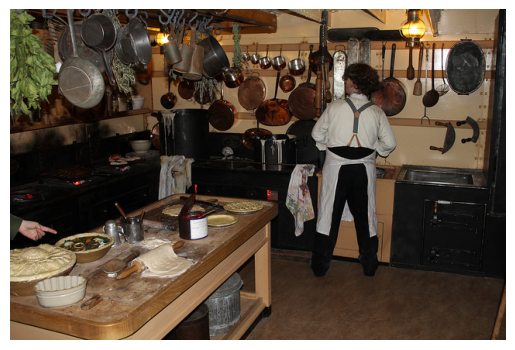

In [54]:
img = cv2.imread(img_path)

if img is None:
    print("Error loading image")
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')

In [55]:
ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

print(anns[0])

{'segmentation': [[224.24, 297.18, 228.29, 297.18, 234.91, 298.29, 243.0, 297.55, 249.25, 296.45, 252.19, 294.98, 256.61, 292.4, 254.4, 264.08, 251.83, 262.61, 241.53, 260.04, 235.27, 259.67, 230.49, 259.67, 233.44, 255.25, 237.48, 250.47, 237.85, 243.85, 237.11, 240.54, 234.17, 242.01, 228.65, 249.37, 224.24, 255.62, 220.93, 262.61, 218.36, 267.39, 217.62, 268.5, 218.72, 295.71, 225.34, 297.55]], 'area': 1481.3806499999994, 'iscrowd': 0, 'image_id': 397133, 'bbox': [217.62, 240.54, 38.99, 57.75], 'category_id': 44, 'id': 82445}


(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

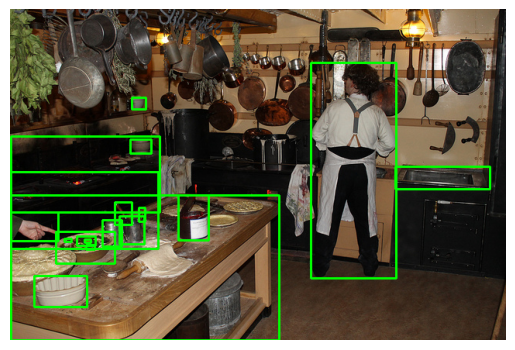

In [56]:
for ann in anns:
    x, y, w, h = ann['bbox']

    # Draw rectangle
    cv2.rectangle(img,
                  (int(x), int(y)),
                  (int(x + w), int(y + h)),
                  (0, 255, 0),
                  2)

plt.imshow(img)
plt.axis('off')

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

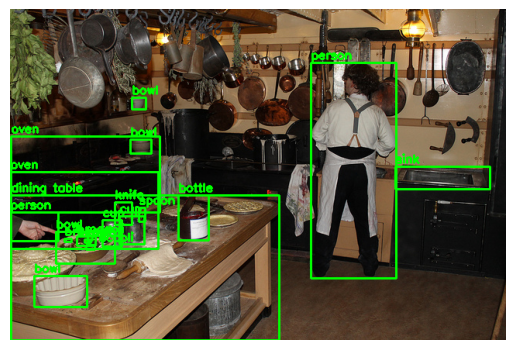

In [57]:
for ann in anns:
    x, y, w, h = ann['bbox']
    cat_id = ann['category_id']

    cat_name = coco.loadCats(cat_id)[0]['name']

    cv2.rectangle(img,
                  (int(x), int(y)),
                  (int(x + w), int(y + h)),
                  (0, 255, 0),
                  2)

    cv2.putText(img, cat_name,
                (int(x), int(y - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2)

plt.imshow(img)
plt.axis('off')

## Pretraining in Object Detection

Pretraining refers to training a model on a large dataset before using it for a specific task.

In object detection, models are pretrained on large datasets like COCO to learn:
- Visual features (edges, shapes, textures)
- Object patterns
- Spatial relationships

## Why Pretraining is Important

Training from scratch requires:
- Large datasets
- High computation
- Long training time

Pretrained models:
- Already understand general visual features
- Require less data for new tasks
- Converge faster

## Training on COCO Dataset

The COCO dataset provides:
- Images
- Bounding boxes
- Class labels

During training:
1. The image is passed into the model
2. The model predicts bounding boxes and classes
3. Predictions are compared with ground truth annotations
4. Loss is computed and model weights are updated

## Training Pipeline

Image → Model → Predictions → Compare with Ground Truth → Compute Loss → Update Model

<img src="https://www.mdpi.com/micromachines/micromachines-14-00442/article_deploy/html/images/micromachines-14-00442-g001.png" width="800" height="400">

## What the Model Learns

The model learns:
- Where objects are (localization)
- What objects are (classification)
- Confidence of predictions

## Loss Function

The loss combines:
- Localization loss (bounding box accuracy)
- Classification loss (correct label prediction)

The goal is to minimize both errors during training.

## Key Insight

Pretrained models do not memorize images.
They learn patterns such as:
- Edges
- Shapes
- Object structures

These features generalize to new images.

## Transition to YOLO

Different models use different approaches for detection.

Traditional models like Faster R-CNN use region proposals.

YOLO treats detection as a single regression problem:
- Predicting bounding boxes and classes in one pass

Next, we explore how YOLO uses grid-based predictions.

## What is YOLO?

YOLO (You Only Look Once) is an object detection model that performs detection in a single forward pass.

Unlike traditional methods:
- It does NOT generate region proposals
- It directly predicts bounding boxes and class probabilities

## Key Idea

YOLO treats object detection as a regression problem.

Instead of:
- Searching for objects

It:
- Predicts everything at once

## Grid-based Detection

YOLO divides the image into an S × S grid.

Each grid cell is responsible for detecting objects whose center falls inside it.

<img src="https://miro.medium.com/1%2AtWAIXZ7T-pGAeWYBlnEOYw.png" width="800" height="400">


## Prediction per Grid Cell

Each grid cell predicts:

- B bounding boxes
- Confidence scores
- C class probabilities

## Output Tensor

YOLO outputs:

S × S × (B × 5 + C)

Where:
- S × S → number of grid cells
- B → number of bounding boxes per cell
- 5 → (x, y, w, h, confidence)
- C → number of classes

(x, y) → center

(w, h) → size

confidence → objectness

## Detection Process

1. Image is divided into grid
2. Each grid predicts boxes + classes
3. Model outputs many candidate boxes
4. Non-Max Suppression removes duplicates

<img src="https://media.licdn.com/dms/image/v2/D4D12AQHRMh0c5QaVBw/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1716188730720?e=2147483647&t=VRLVC94Eo-1Jp3zCHHhISOvVaSOHKfgaklDpM6znG1A&v=beta" width="800" height="400">


## YOLO vs Faster R-CNN

| Feature | YOLO | Faster R-CNN |
|--------|------|--------------|
| Speed | Very fast | Slower |
| Approach | Single-stage | Two-stage |
| Accuracy | Good | Higher (generally) |
| Real-time | Yes | Limited |

## Connection to COCO Dataset

COCO provides:
(x, y, width, height)

YOLO requires:
(x_center, y_center, width, height) normalized

So we convert COCO annotations into YOLO format before training.

# **Section: COCO → YOLO Conversion + Visualization**

## Goal

We will:
1. Take one COCO annotation
2. Convert it into YOLO format
3. Visualize both bounding boxes on the same image

In [60]:
img_id = coco.getImgIds()[0]
img_info = coco.loadImgs(img_id)[0]

img_path = os.path.join("val2017", img_info['file_name'])

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img.shape

ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

In [61]:
ann = anns[0] # bottle object

x, y, bw, bh = ann['bbox']   # COCO format

In [62]:
# COCO → YOLO
x_center = (x + bw / 2) / w
y_center = (y + bh / 2) / h

bw_yolo = bw / w
bh_yolo = bh / h

In [63]:
# YOLO → pixel
x_pixel = x_center * w
y_pixel = y_center * h

bw_pixel = bw_yolo * w
bh_pixel = bh_yolo * h

x1_yolo = int(x_pixel - bw_pixel / 2)
y1_yolo = int(y_pixel - bh_pixel / 2)
x2_yolo = int(x_pixel + bw_pixel / 2)
y2_yolo = int(y_pixel + bh_pixel / 2)

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

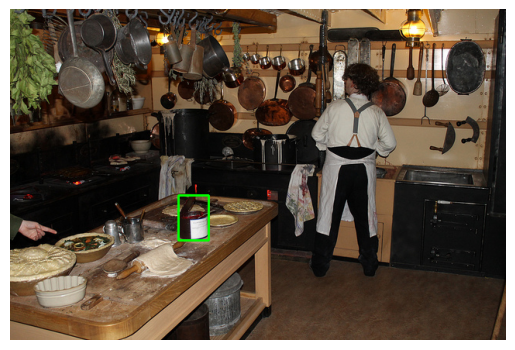

In [66]:
img_copy = img.copy()

#  COCO box (original)
cv2.rectangle(img_copy,
              (int(x), int(y)),
              (int(x + bw), int(y + bh)),
              (255, 0, 0), 2)

#  YOLO box (converted)
cv2.rectangle(img_copy,
              (x1_yolo, y1_yolo),
              (x2_yolo, y2_yolo),
              (0, 255, 0), 2)

plt.imshow(img_copy)
plt.axis('off')

## Insight

Although COCO and YOLO use different formats, they represent the same bounding box.

The difference is only in:
- Coordinate system
- Normalization

COCO provides annotations in (x, y, width, height) format, but YOLO requires normalized center-based coordinates. Therefore, we convert the dataset into YOLO format to match the model’s expected input representation.

## Full Connection

COCO → provides bounding boxes  
YOLO → converts them into normalized format  
YOLO model → predicts grid-based tensor  
Post-processing → gives final detected objects

In [68]:
# Install
!pip install ultralytics

from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # lightweight pretrained model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [69]:
img_path = os.path.join("val2017", img_info['file_name'])

results = model(img_path)


image 1/1 /content/val2017/000000397133.jpg: 448x640 2 persons, 1 cup, 4 bowls, 1 potted plant, 1 oven, 1841.7ms
Speed: 76.8ms preprocess, 1841.7ms inference, 79.0ms postprocess per image at shape (1, 3, 448, 640)


## Detection Flow

1. Each grid cell predicts multiple boxes
2. Each box has:
   - location
   - confidence
3. Class probabilities are applied
4. Low-confidence boxes are removed
5. Non-Max Suppression keeps best boxes

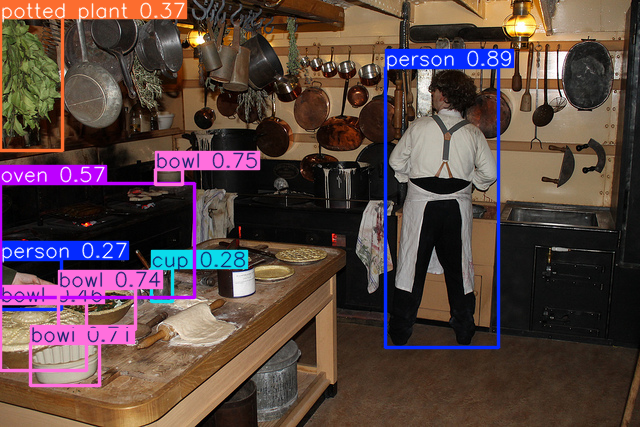

In [71]:
results[0].show()



<img src="https://i.sstatic.net/aUcNf.jpg" width="800" height="400">


In [86]:
class_names = model.names
print(class_names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [72]:
boxes = results[0].boxes

for box in boxes:
    print("Class:", int(box.cls))
    print("Confidence:", float(box.conf))
    print("Coordinates:", box.xyxy)
    print("------")

Class: 0
Confidence: 0.893030047416687
Coordinates: tensor([[385.2894,  67.6295, 498.8463, 347.5894]])
------
Class: 45
Confidence: 0.7473417520523071
Coordinates: tensor([[155.1975, 169.1813, 182.2119, 184.5858]])
------
Class: 45
Confidence: 0.7430888414382935
Coordinates: tensor([[ 58.2354, 288.7991, 135.5101, 329.4897]])
------
Class: 45
Confidence: 0.7132402658462524
Coordinates: tensor([[ 30.7475, 343.4948,  99.8736, 385.9079]])
------
Class: 69
Confidence: 0.5717453956604004
Coordinates: tensor([[  0.0000, 183.3797, 194.7497, 297.3693]])
------
Class: 45
Confidence: 0.4620475471019745
Coordinates: tensor([[  0.0000, 303.0087,  86.4995, 370.4733]])
------
Class: 58
Confidence: 0.3650931715965271
Coordinates: tensor([[0.0000e+00, 1.4673e-01, 6.2023e+01, 1.5059e+02]])
------
Class: 41
Confidence: 0.2776661217212677
Coordinates: tensor([[151.3400, 268.1083, 172.3218, 301.7816]])
------
Class: 0
Confidence: 0.2667217552661896
Coordinates: tensor([[  0.0000, 259.7126,  61.0867, 309.23

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

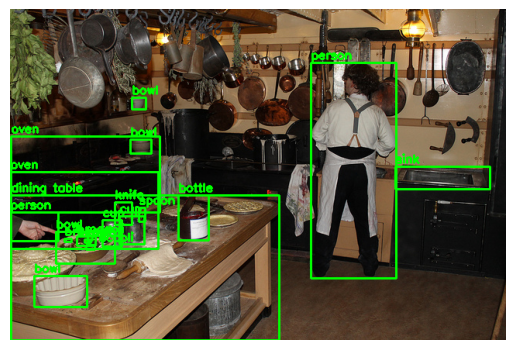

In [76]:
anns = coco.loadAnns(ann_ids) # compare with the ground truth

for ann in anns:
    x, y, w, h = ann['bbox']
    cat_id = ann['category_id']

    cat_name = coco.loadCats(cat_id)[0]['name']

    cv2.rectangle(img,
                  (int(x), int(y)),
                  (int(x + w), int(y + h)),
                  (0, 255, 0),
                  2)

    cv2.putText(img, cat_name,
                (int(x), int(y - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                2)

plt.imshow(img)
plt.axis('off')

## Comparison

Ground truth:
- Comes from COCO annotations

Predictions:
- Generated by YOLO model

We compare them to evaluate performance.

## Evaluation Metric

Object detection models are evaluated using:

- IoU (Intersection over Union)
- mAP (mean Average Precision)

Higher IoU indicates better overlap between predicted and actual boxes.

In [88]:
img_path = os.path.join("/content/example image.jpeg")
img_path

'/content/example image.jpeg'

In [89]:
test_result = model(img_path)


image 1/1 /content/example image.jpeg: 640x480 2 bottles, 1 laptop, 1286.0ms
Speed: 72.0ms preprocess, 1286.0ms inference, 25.1ms postprocess per image at shape (1, 3, 640, 480)


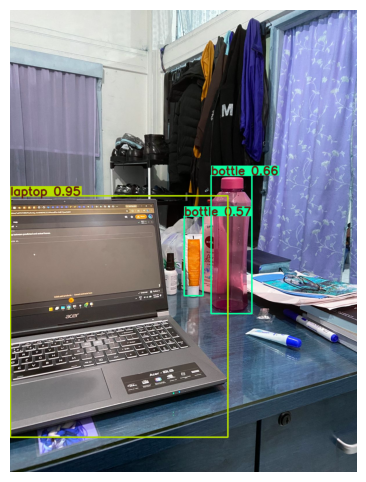

In [92]:
import matplotlib.pyplot as plt

# Get the image with bounding boxes drawn by YOLO
img_with_boxes = test_result[0].plot()

# Create a new figure with a smaller size (e.g., 8x6 inches)
plt.figure(figsize=(8, 6))
plt.imshow(img_with_boxes)
plt.axis('off') # Hide axes for a cleaner look
plt.show()